# 🍌 Smart Folder Augmentation Notebook
> Augments any single class folder to your target image count  
> ✅ No black borders &nbsp;|&nbsp; ✅ No fill artifacts &nbsp;|&nbsp; ✅ No TensorFlow needed
---

## 📦 Step 1 — Install Libraries

In [1]:
# Run this once if Pillow/numpy aren't installed
import sys, subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'Pillow', 'numpy', '-q'])
print('✅ Libraries ready!')

✅ Libraries ready!


## 📥 Step 2 — Imports

In [2]:
import os, random
from pathlib import Path
import numpy as np
from PIL import Image, ImageEnhance, ImageFilter
import matplotlib.pyplot as plt
print('✅ All imports done!')

✅ All imports done!


## ⚙️ Step 3 — Configuration
> **Only edit this cell.** Set your folder path and target count.

| Variable | What it does |
|---|---|
| `FOLDER_PATH` | Path to the single class folder you want to augment |
| `TARGET_COUNT` | How many total images you want after augmentation |
| `IMG_SIZE` | All images will be resized to this (width, height) |
| `SEED` | Makes results reproducible — same seed = same augmentations |


In [14]:
# ────────────────────────────────────────────
# ✏️  CHANGE THESE
# ────────────────────────────────────────────
FOLDER_PATH  = r'C:/Fruit_Fresh_pro/dataset_split/val/banana/premium'
TARGET_COUNT = 200
IMG_SIZE     = (224, 224)   # (width, height)
SEED         = 42
# ────────────────────────────────────────────

random.seed(SEED)
np.random.seed(SEED)
SUPPORTED = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

print(f'📂 Folder  : {FOLDER_PATH}')
print(f'🎯 Target  : {TARGET_COUNT} images')
print(f'📐 Size    : {IMG_SIZE}')

📂 Folder  : C:/Fruit_Fresh_pro/dataset_split/val/banana/premium
🎯 Target  : 200 images
📐 Size    : (224, 224)


## 🔧 Step 4 — Augmentation Pipeline

Each transform fires **independently** with its own probability.  
Multiple transforms stack → massive diversity from just a few source images.

### Why each augmentation?

| # | Augmentation | Probability | Why it helps |
|---|---|---|---|
| 1 | **Horizontal Flip** | 50% | Fruits appear in any orientation |
| 2 | **Vertical Flip** | 30% | Adds texture diversity |
| 3 | **Rotation + crop-resize** | 60% | `expand=True` avoids black corners entirely |
| 4 | **Random Crop + Resize** | 50% | Partial fruit view → teaches texture focus |
| 5 | **Brightness** | 65% | Simulates sunlight / shade / warehouse light |
| 6 | **Contrast** | 55% | Washed-out vs punchy camera simulation |
| 7 | **Saturation** | 55% | Camera color rendering varies widely |
| 8 | **Sharpness** | 45% | Lens blur or over-sharpened phone cameras |
| 9 | **Gaussian Blur** | 35% | Defocus / motion blur simulation |
| 10 | **Gaussian Noise** | 35% | Sensor noise in low-light / cheap cameras |
| 11 | **UnsharpMask** | 30% | Reveals surface texture (key for fresh/rotten) |
| 12 | **Hue Shift (R/B)** | 20% | Simulates different white balance settings |


In [15]:
def augment(img: Image.Image) -> Image.Image:
    """
    Applies a random stack of augmentations.
    No fill_mode artifacts. No black borders.
    """
    img = img.convert('RGB')

    # 1. Horizontal Flip
    if random.random() < 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)

    # 2. Vertical Flip
    if random.random() < 0.3:
        img = img.transpose(Image.FLIP_TOP_BOTTOM)

    # 3. Rotation — expand=True fills with real content, then resize → NO black corners
    if random.random() < 0.6:
        angle = random.uniform(-30, 30)
        img = img.rotate(angle, resample=Image.BILINEAR, expand=True)
        img = img.resize(IMG_SIZE, Image.BILINEAR)

    # 4. Random Crop + Resize (zoom simulation — no black added)
    if random.random() < 0.5:
        w, h = img.size
        ratio = random.uniform(0.70, 0.95)
        nw, nh = int(w * ratio), int(h * ratio)
        left = random.randint(0, w - nw)
        top  = random.randint(0, h - nh)
        img  = img.crop((left, top, left + nw, top + nh))
        img  = img.resize(IMG_SIZE, Image.BILINEAR)

    # 5. Brightness
    if random.random() < 0.65:
        img = ImageEnhance.Brightness(img).enhance(random.uniform(0.55, 1.6))

    # 6. Contrast
    if random.random() < 0.55:
        img = ImageEnhance.Contrast(img).enhance(random.uniform(0.6, 1.6))

    # 7. Saturation
    if random.random() < 0.55:
        img = ImageEnhance.Color(img).enhance(random.uniform(0.4, 1.9))

    # 8. Sharpness
    if random.random() < 0.45:
        img = ImageEnhance.Sharpness(img).enhance(random.uniform(0.3, 2.8))

    # 9. Gaussian Blur (mild — simulates defocus)
    if random.random() < 0.35:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.4, 1.8)))

    # 10. Gaussian Noise (sensor noise simulation)
    if random.random() < 0.35:
        arr   = np.array(img, dtype=np.float32)
        noise = np.random.normal(0, random.uniform(4, 18), arr.shape)
        arr   = np.clip(arr + noise, 0, 255).astype(np.uint8)
        img   = Image.fromarray(arr)

    # 11. UnsharpMask (enhances surface texture — critical for fresh vs rotten)
    if random.random() < 0.3:
        img = img.filter(ImageFilter.UnsharpMask(
            radius=random.uniform(1, 3),
            percent=random.randint(100, 200),
            threshold=3
        ))

    # 12. Hue shift via R/B channel nudge (white balance simulation)
    if random.random() < 0.2:
        arr = np.array(img)
        shift = random.randint(-15, 15)
        arr[:, :, 0] = np.clip(arr[:, :, 0].astype(int) + shift, 0, 255)
        arr[:, :, 2] = np.clip(arr[:, :, 2].astype(int) - shift, 0, 255)
        img = Image.fromarray(arr.astype(np.uint8))

    return img.resize(IMG_SIZE, Image.BILINEAR)


print('✅ augment() function ready!')

✅ augment() function ready!


## 👁️ Step 5 — Preview Augmentations
Run this before augmenting to **visually confirm** the transforms look good on your actual images.

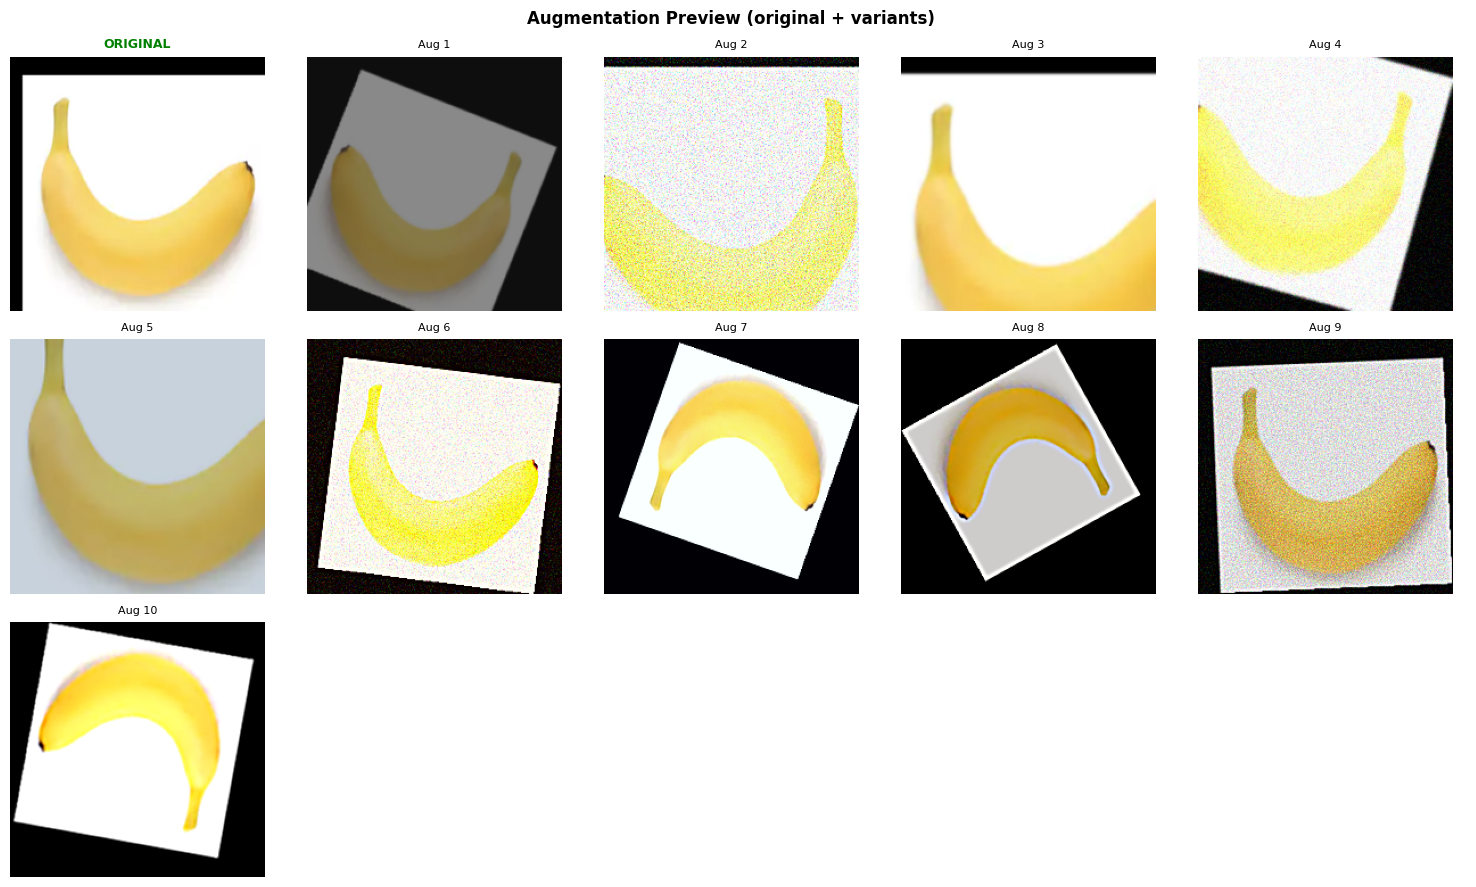

In [16]:
def preview(folder_path, n=10):
    folder = Path(folder_path)
    imgs   = [p for p in folder.iterdir() if p.suffix.lower() in SUPPORTED]
    if not imgs:
        print('❌ No images found!')
        return

    src = Image.open(random.choice(imgs)).convert('RGB').resize(IMG_SIZE)

    cols = 5
    rows = (n + 1 + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = axes.flatten()

    axes[0].imshow(src)
    axes[0].set_title('ORIGINAL', fontweight='bold', color='green', fontsize=9)
    axes[0].axis('off')

    for i in range(1, n + 1):
        axes[i].imshow(augment(src.copy()))
        axes[i].set_title(f'Aug {i}', fontsize=8)
        axes[i].axis('off')

    for j in range(n + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle('Augmentation Preview (original + variants)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

preview(FOLDER_PATH)

## 📊 Step 6 — Scan Folder
Check current image count and how many will be generated.

In [17]:
folder = Path(FOLDER_PATH)

if not folder.exists():
    raise FileNotFoundError(f'❌ Folder not found: {folder}')

existing = [p for p in folder.iterdir() if p.suffix.lower() in SUPPORTED]
current  = len(existing)
needed   = max(0, TARGET_COUNT - current)

print(f'📂 Folder    : {folder}')
print(f'🖼️  Current   : {current} images')
print(f'🎯 Target    : {TARGET_COUNT} images')
print(f'⚙️  To generate: {needed} augmented images')

if current == 0:
    raise ValueError('❌ No images in folder!')
elif needed == 0:
    print('✅ Already at target — nothing to do!')

📂 Folder    : C:\Fruit_Fresh_pro\dataset_split\val\banana\premium
🖼️  Current   : 15 images
🎯 Target    : 200 images
⚙️  To generate: 185 augmented images


## 🚀 Step 7 — Run Augmentation
> This saves augmented images directly into your folder with prefix `aug_XXXXX.jpg`

In [18]:
if needed > 0:
    # Load all source images into memory (faster than re-reading disk each time)
    src_imgs = []
    for p in existing:
        try:
            img = Image.open(p).convert('RGB').resize(IMG_SIZE, Image.BILINEAR)
            src_imgs.append(img)
        except Exception as e:
            print(f'  [WARN] Skipped {p.name}: {e}')

    print(f'Loaded {len(src_imgs)} source images into memory')
    print(f'Generating {needed} augmented images...\n')

    for i in range(needed):
        base      = random.choice(src_imgs)
        aug_img   = augment(base.copy())
        save_path = folder / f'aug_{i:05d}.jpg'
        aug_img.save(save_path, 'JPEG', quality=92)

        if (i + 1) % 50 == 0 or (i + 1) == needed:
            print(f'  [{i+1:>5}/{needed}] saved → {save_path.name}')

    final = len([p for p in folder.iterdir() if p.suffix.lower() in SUPPORTED])
    print(f'\n🎉 Done! Total images now: {final}')
else:
    print('✅ Nothing to generate — already at target!')

Loaded 15 source images into memory
Generating 185 augmented images...

  [   50/185] saved → aug_00049.jpg
  [  100/185] saved → aug_00099.jpg
  [  150/185] saved → aug_00149.jpg
  [  185/185] saved → aug_00184.jpg

🎉 Done! Total images now: 200


## ✅ Step 8 — Verify Final Count

In [19]:
all_imgs = [p for p in folder.iterdir() if p.suffix.lower() in SUPPORTED]
orig  = [p for p in all_imgs if not p.name.startswith('aug_')]
augs  = [p for p in all_imgs if p.name.startswith('aug_')]

print(f'📊 Final Summary')
print(f'   Original images  : {len(orig)}')
print(f'   Augmented images : {len(augs)}')
print(f'   Total            : {len(all_imgs)}')

status = '✅ Target reached!' if len(all_imgs) >= TARGET_COUNT else '⚠️ Below target'
print(f'   Status           : {status}')

📊 Final Summary
   Original images  : 15
   Augmented images : 185
   Total            : 200
   Status           : ✅ Target reached!


## 🖼️ Step 9 — Preview Saved Augmented Images

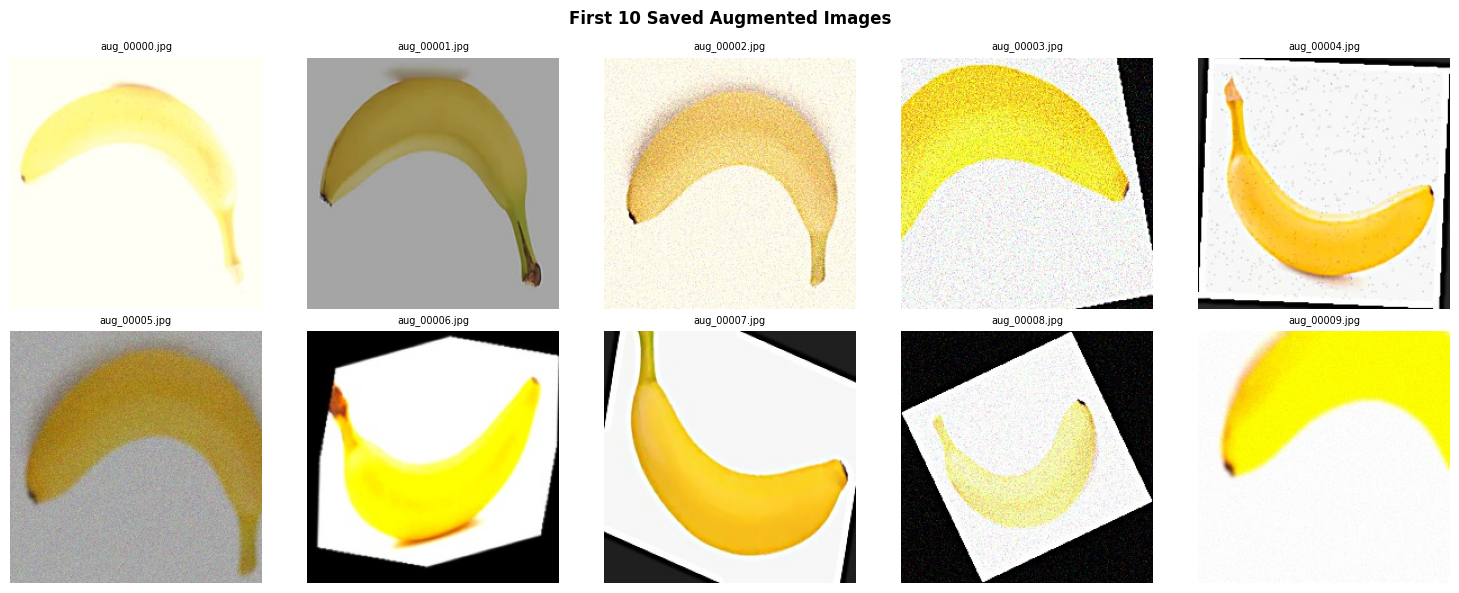

In [20]:
saved_augs = sorted(folder.glob('aug_*.jpg'))[:10]

if not saved_augs:
    print('No aug_ files found to preview.')
else:
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    for i, p in enumerate(saved_augs):
        axes[i].imshow(Image.open(p))
        axes[i].set_title(p.name, fontsize=7)
        axes[i].axis('off')
    for j in range(len(saved_augs), len(axes)):
        axes[j].axis('off')
    plt.suptitle('First 10 Saved Augmented Images', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()